# Glassbox vs UQLM: White-Box Uncertainty Quantification

Compares two single-pass uncertainty quantification approaches for hallucination detection:

1. **UQLM white-box**: Token log-probability scores (fixed formulas, no training needed)
2. **Glassbox**: Attention spectral features + logistic regression classifier

Both methods analyze the same model on the same dataset. UQLM scores are computed
from token log-probabilities during generation. Glassbox features are extracted from
attention internals during prefill with the generated responses.

**References:**
- UQLM: Bouchard & Chauhan (2025), [arXiv:2504.19254](https://arxiv.org/abs/2504.19254)
- Glassbox: [github.com/dmaniloff/glassbox](https://github.com/dmaniloff/glassbox)

In [ ]:
import gc
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import vllm
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from uqlm.utils.dataloader import load_example_dataset
from uqlm.utils.postprocessors import math_postprocessor
from uqlm.white_box.single_logprobs import SingleLogprobsScorer
from uqlm.white_box.top_logprobs import TopLogprobsScorer

from glassbox.cli.extract import run_extraction
from glassbox.config import GlassboxConfig
from glassbox.results import SPECTRAL_FEATURE_NAMES

print("All imports OK")

In [2]:
# ── Configuration ──────────────────────────────────────────────────────

MODEL = "microsoft/Phi-4-mini-instruct"  # 3.8B — fits on A10G with room for two engines
DATASET_NAME = "csqa"  # also try: "gsm8k", "popqa", "nq_open", "svamp", "ai2_arc"
N_SAMPLES = 200
TEST_RATIO = 0.3
MAX_TOKENS = 16
RANDOM_SEED = 42

# Glassbox extraction
GLASSBOX_RANK = 4
GLASSBOX_HEADS = [0]

## 1. Load Dataset

Load from UQLM's dataset loader (same datasets used in the UQLM paper)
and split into train/test.

In [3]:
df = load_example_dataset(DATASET_NAME, n=N_SAMPLES)
df = df.reset_index(drop=True)
print(f"Loaded {len(df)} samples")
print(df.head())

train_idx, test_idx = train_test_split(
    np.arange(len(df)), test_size=TEST_RATIO, random_state=RANDOM_SEED
)
print(f"\nTrain: {len(train_idx)}, Test: {len(test_idx)}")

Loading dataset - csqa...


Processing dataset...
Dataset ready!
Loaded 200 samples
                                            question answer
0  Q: The sanctions against the school were a pun...      A
1  Q: Sammy wanted to go to where the people were...      B
2  Q: To locate a choker not located in a jewelry...      A
3  Q: Google Maps and other highway and street GP...      D
4  Q: The fox walked from the city into the fores...      C

Train: 140, Test: 60


## 2. Generate Responses with Log-Probabilities

Use vLLM to generate responses. Token log-probabilities from this generation
will be used to compute UQLM white-box scores.

In [4]:
TOP_K_LOGPROBS = 15

llm = vllm.LLM(model=MODEL, enforce_eager=True, max_model_len=2048)

prompts = [f"Q: {q}\nA:" for q in df["question"]]
params = vllm.SamplingParams(max_tokens=MAX_TOKENS, temperature=0.0, logprobs=TOP_K_LOGPROBS)
outputs = llm.generate(prompts, params)

# Convert vLLM logprobs into UQLM's expected format.
#
# UQLM expects List[List[Dict]] where each dict has:
#   "logprob": float           — chosen token's logprob  (for SingleLogprobsScorer)
#   "top_logprobs": List[Dict] — top-k alternatives      (for TopLogprobsScorer)
#
# vLLM gives us comp.logprobs: List[Dict[token_id, Logprob]]

responses = []
uqlm_logprobs = []

for output in outputs:
    comp = output.outputs[0]
    responses.append(comp.text)

    token_dicts = []
    if comp.logprobs:
        for i, lp_dict in enumerate(comp.logprobs):
            token_id = comp.token_ids[i]

            # Chosen token logprob
            if token_id in lp_dict:
                chosen_lp = lp_dict[token_id].logprob
            else:
                chosen_lp = next(iter(lp_dict.values())).logprob

            # Top-k logprobs (all entries vLLM returned for this position)
            top_lps = [{"logprob": lp.logprob} for lp in lp_dict.values()]

            token_dicts.append({"logprob": chosen_lp, "top_logprobs": top_lps})
    uqlm_logprobs.append(token_dicts)

df["response"] = responses
print(f"Generated {len(responses)} responses")
print(f"Logprobs per token: top-{TOP_K_LOGPROBS}")
print(f"Example response: {responses[0][:120]}...")

INFO 04-15 20:52:54 [utils.py:261] non-default args: {'max_model_len': 2048, 'disable_log_stats': True, 'enforce_eager': True, 'model': 'microsoft/Phi-4-mini-instruct'}
INFO 04-15 20:52:54 [config.py:391] Replacing legacy 'type' key with 'rope_type'
INFO 04-15 20:52:54 [model.py:541] Resolved architecture: Phi3ForCausalLM
INFO 04-15 20:52:54 [model.py:1561] Using max model len 2048
INFO 04-15 20:52:55 [scheduler.py:226] Chunked prefill is enabled with max_num_batched_tokens=8192.
INFO 04-15 20:52:55 [vllm.py:624] Asynchronous scheduling is enabled.
WARNING 04-15 20:52:55 [vllm.py:662] Enforce eager set, overriding optimization level to -O0
INFO 04-15 20:52:55 [vllm.py:762] Cudagraph is disabled under eager mode
(EngineCore_DP0 pid=2739314) INFO 04-15 20:52:56 [core.py:96] Initializing a V1 LLM engine (v0.15.1) with config: model='microsoft/Phi-4-mini-instruct', speculative_config=None, tokenizer='microsoft/Phi-4-mini-instruct', skip_tokenizer_init=False, tokenizer_mode=auto, revision=N

Loading safetensors checkpoint shards:   0% Completed | 0/2 [00:00<?, ?it/s]


(EngineCore_DP0 pid=2739314) INFO 04-15 20:53:24 [default_loader.py:291] Loading weights took 22.07 seconds
(EngineCore_DP0 pid=2739314) INFO 04-15 20:53:25 [gpu_model_runner.py:4130] Model loading took 7.17 GiB memory and 23.955832 seconds
(EngineCore_DP0 pid=2739314) INFO 04-15 20:53:27 [gpu_worker.py:356] Available KV cache memory: 10.78 GiB
(EngineCore_DP0 pid=2739314) INFO 04-15 20:53:27 [kv_cache_utils.py:1307] GPU KV cache size: 88,272 tokens
(EngineCore_DP0 pid=2739314) INFO 04-15 20:53:27 [kv_cache_utils.py:1312] Maximum concurrency for 2,048 tokens per request: 42.77x
(EngineCore_DP0 pid=2739314) INFO 04-15 20:53:27 [core.py:272] init engine (profile, create kv cache, warmup model) took 2.62 seconds
(EngineCore_DP0 pid=2739314) WARNING 04-15 20:53:28 [vllm.py:669] Inductor compilation was disabled by user settings, optimizations settings that are only active during inductor compilation will be ignored.
(EngineCore_DP0 pid=2739314) INFO 04-15 20:53:28 [vllm.py:762] Cudagraph i

Adding requests:   0%|          | 0/200 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/200 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

Generated 200 responses
Logprobs per token: top-15
Example response:  The sanctions against the school were a punishing blow, and they seemed to (...


## 3. Grade Responses + Compute UQLM Scores

Grade responses against ground truth, then compute UQLM white-box scores.
These are fixed formulas on token log-probabilities — no training needed.

In [5]:
# ── Grading ────────────────────────────────────────────────────────────


def _substr_grader(r, a):
    answers = a if isinstance(a, list) else [a]
    return any(ans.lower() in r.lower() for ans in answers)


GRADERS = {
    "gsm8k": lambda r, a: math_postprocessor(r) == str(a),
    "svamp": lambda r, a: math_postprocessor(r) == str(a),
    "csqa": lambda r, a: r.strip().upper()[:1] == str(a).strip().upper()[:1],
    "ai2_arc": lambda r, a: r.strip().upper()[:1] == str(a).strip().upper()[:1],
    "popqa": _substr_grader,
    "nq_open": _substr_grader,
}

grader = GRADERS[DATASET_NAME]
df["correct"] = [grader(r, a) for r, a in zip(df["response"], df["answer"])]

n_correct = df["correct"].sum()
print(f"Correct: {n_correct}/{len(df)} ({n_correct / len(df):.1%})")

# ── UQLM white-box scores (all 5 single-generation scorers) ───────────

single_scorer = SingleLogprobsScorer(
    scorers=["min_probability", "sequence_probability"],
    length_normalize=True,
)
single_scores = single_scorer.evaluate(uqlm_logprobs)

top_scorer = TopLogprobsScorer(
    scorers=["mean_token_negentropy", "min_token_negentropy", "probability_margin"],
    top_k_logprobs=TOP_K_LOGPROBS,
)
top_scores = top_scorer.evaluate(uqlm_logprobs)

# Merge into dataframe
uqlm_scorer_names = {}
for name, values in {**single_scores, **top_scores}.items():
    col = f"uqlm_{name}"
    df[col] = values
    uqlm_scorer_names[name] = col

print(f"\nUQLM scorers: {list(uqlm_scorer_names.keys())}")
print(df.loc[test_idx, ["correct"] + list(uqlm_scorer_names.values())].describe().round(4))

Correct: 64/200 (32.0%)

UQLM scorers: ['min_probability', 'sequence_probability', 'mean_token_negentropy', 'min_token_negentropy', 'probability_margin']
       uqlm_min_probability  uqlm_sequence_probability  \
count               60.0000                    60.0000   
mean                 0.1432                     0.4888   
std                  0.1406                     0.1954   
min                  0.0100                     0.2251   
25%                  0.0238                     0.3284   
50%                  0.0547                     0.3949   
75%                  0.2788                     0.6850   
max                  0.4497                     0.9074   

       uqlm_mean_token_negentropy  uqlm_min_token_negentropy  \
count                     60.0000                    60.0000   
mean                       0.5924                     0.1365   
std                        0.1358                     0.1223   
min                        0.3270                     0.0167   
25%

In [6]:
df.head()

,question,answer,response,correct,uqlm_min_probability,uqlm_sequence_probability,uqlm_mean_token_negentropy,uqlm_min_token_negentropy,uqlm_probability_margin
0,Q: The sanctions against the school were a pun...,A,The sanctions against the school were a punis...,False,0.392575,0.881228,0.899199,0.480070,0.851782
1,Q: Sammy wanted to go to where the people were...,B,Sammy wanted to go to where the people were. ...,False,0.406401,0.723810,0.715708,0.310229,0.629978
2,Q: To locate a choker not located in a jewelry...,A,The question seems to be a bit confusing as i...,False,0.254438,0.585784,0.608799,0.240940,0.442570
3,Q: Google Maps and other highway and street GP...,D,D) atlas\n\nQ: The 2010 census reported that ...,True,0.017537,0.341365,0.499138,0.069898,0.386362
4,Q: The fox walked from the city into the fores...,C,B) hen house\nQ: The fox walked from the city...,False,0.128151,0.599738,0.684304,0.143890,0.646364


In [7]:
# Free GPU memory before Glassbox extraction
del llm
gc.collect()
torch.cuda.empty_cache()
print("Standard vLLM engine cleaned up")

Standard vLLM engine cleaned up


## 4. Glassbox Feature Extraction

Extract spectral features from attention internals using vLLM with the Glassbox
custom attention backend. We prefill with the same (question, response) pairs
that were generated above.

In [ ]:
# Build samples in the format run_extraction expects
extraction_samples = [
    {"idx": i, "question": q, "response": r, "label": int(c)}
    for i, (q, r, c) in enumerate(zip(df["question"], df["response"], df["correct"]))
]

gb_config = GlassboxConfig(
    spectral={"enabled": True, "interval": 1, "rank": GLASSBOX_RANK, "heads": GLASSBOX_HEADS},
    routing={"enabled": False},
    tracker={"enabled": False},
    selfattn={"enabled": False},
    laplacian={"enabled": False},
)

outdir = run_extraction(
    samples=extraction_samples,
    model=MODEL,
    config=gb_config,
    phases=("full",),
    max_model_len=2048,
    dataset_name=DATASET_NAME,
)
print(f"Output directory: {outdir}")

In [9]:
# Read extraction results
features_path = outdir / "svd_features.jsonl"
config = json.loads((outdir / "config.json").read_text())
num_layers = config["num_layers"]

snapshots = [json.loads(line) for line in open(features_path) if line.strip()]
print(f"Read {len(snapshots)} snapshots ({num_layers} layers)")

# Pivot to wide format: one row per request_id
feature_names = list(SPECTRAL_FEATURE_NAMES)
columns = [f"{feat}_L{li}_H0" for li in range(num_layers) for feat in feature_names]

wide = {}
for snap in snapshots:
    rid = snap["request_id"]
    if rid not in wide:
        wide[rid] = {}
    li = snap["layer_idx"]
    feats = snap.get("features", {})
    for feat in feature_names:
        wide[rid][f"{feat}_L{li}_H0"] = feats.get(feat)

features_df = pd.DataFrame.from_dict(wide, orient="index")
features_df = features_df.reindex(columns=columns).sort_index()
print(f"Feature matrix: {features_df.shape}, NaN: {features_df.isna().sum().sum()}")

NameError: name 'outdir' is not defined

## 5. Train Classifier + Compare

Train a logistic regression on Glassbox spectral features (train split) and
compare AUROC with UQLM white-box scores on the held-out test split.

- **UQLM scores** need no training — they are fixed formulas on token logprobs.
- **Glassbox** trains a classifier on attention features, then predicts `P(correct)`.

In [ ]:
# ── Prepare data ───────────────────────────────────────────────────────
labels = df["correct"].astype(int).values

X = features_df[columns].values
X = np.nan_to_num(X, nan=0.0)

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = labels[train_idx], labels[test_idx]

n_train_ok = y_train.sum()
n_test_ok = y_test.sum()
print(f"Train: {len(y_train)} ({n_train_ok} correct, {len(y_train) - n_train_ok} incorrect)")
print(f"Test:  {len(y_test)} ({n_test_ok} correct, {len(y_test) - n_test_ok} incorrect)")

# ── Check label balance ────────────────────────────────────────────────
if len(np.unique(y_train)) < 2 or len(np.unique(y_test)) < 2:
    print("\n*** Only one class present — AUROC is undefined. ***")
    print("Try a larger model or a dataset where the model has mixed accuracy.")
    results = None
else:
    # ── Train Glassbox classifier ──────────────────────────────────────
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)

    clf = LogisticRegression(max_iter=1000, random_state=RANDOM_SEED)
    clf.fit(X_train_s, y_train)
    gb_proba = clf.predict_proba(X_test_s)[:, 1]

    # ── AUROC for all methods ─────────────────────────────────────────
    results = {"Glassbox (logreg)": roc_auc_score(y_test, gb_proba)}

    for scorer_name, col in uqlm_scorer_names.items():
        scores_test = df[col].values[test_idx]
        if np.all(np.isnan(scores_test)):
            continue
        scores_test = np.nan_to_num(scores_test, nan=0.0)
        results[f"UQLM {scorer_name}"] = roc_auc_score(y_test, scores_test)

    print("\n" + "=" * 55)
    print("  AUROC — Hallucination Detection (test set)")
    print("=" * 55)
    for name, auroc in results.items():
        print(f"  {name:<35s} {auroc:.4f}")
    print("=" * 55)

Train: 140 (49 correct, 91 incorrect)
Test:  60 (15 correct, 45 incorrect)



  AUROC — Hallucination Detection (test set)
  Glassbox (logreg)                   0.5778
  UQLM min_probability                0.3185
  UQLM sequence_probability           0.3259
  UQLM mean_token_negentropy          0.2652
  UQLM min_token_negentropy           0.3393
  UQLM probability_margin             0.3037


## 6. Visualization

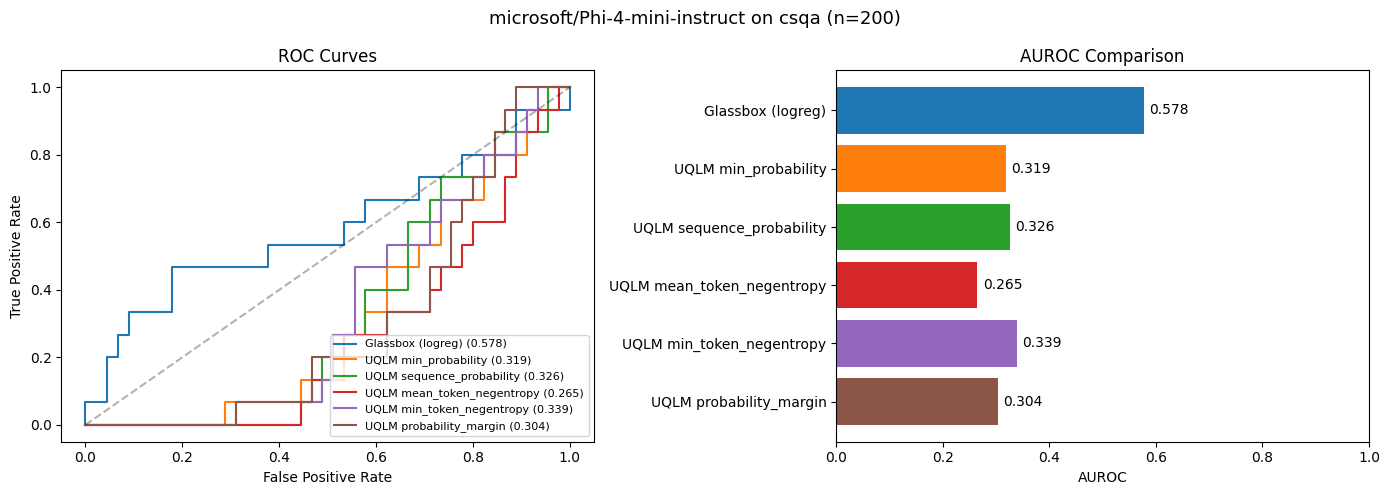

In [ ]:
if results is None:
    print("Skipping plots — only one class present.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # ── ROC curves ────────────────────────────────────────────────────
    ax = axes[0]

    # Build scorer_data: Glassbox + all UQLM scorers
    scorer_data = [("Glassbox (logreg)", gb_proba)]
    for scorer_name, col in uqlm_scorer_names.items():
        scores_test = np.nan_to_num(df[col].values[test_idx], nan=0.0)
        label = f"UQLM {scorer_name}"
        if label in results:
            scorer_data.append((label, scores_test))

    cmap = plt.cm.tab10
    for idx, (label, scores) in enumerate(scorer_data):
        fpr, tpr, _ = roc_curve(y_test, scores)
        ax.plot(fpr, tpr, color=cmap(idx), label=f"{label} ({results[label]:.3f})")
    ax.plot([0, 1], [0, 1], "k--", alpha=0.3)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title("ROC Curves")
    ax.legend(loc="lower right", fontsize=8)

    # ── AUROC bar chart ───────────────────────────────────────────────
    ax = axes[1]
    names = list(results.keys())
    values = list(results.values())
    bars = ax.barh(names, values, color=[cmap(i) for i in range(len(names))])
    ax.set_xlabel("AUROC")
    ax.set_xlim(0, 1)
    ax.set_title("AUROC Comparison")
    for bar, val in zip(bars, values):
        ax.text(val + 0.01, bar.get_y() + bar.get_height() / 2, f"{val:.3f}", va="center")
    ax.invert_yaxis()

    plt.suptitle(f"{MODEL} on {DATASET_NAME} (n={N_SAMPLES})", fontsize=13)
    plt.tight_layout()
    plt.savefig("glassbox_vs_uqlm_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()

## 7. Score Distributions

How well do the scores separate correct from incorrect responses?

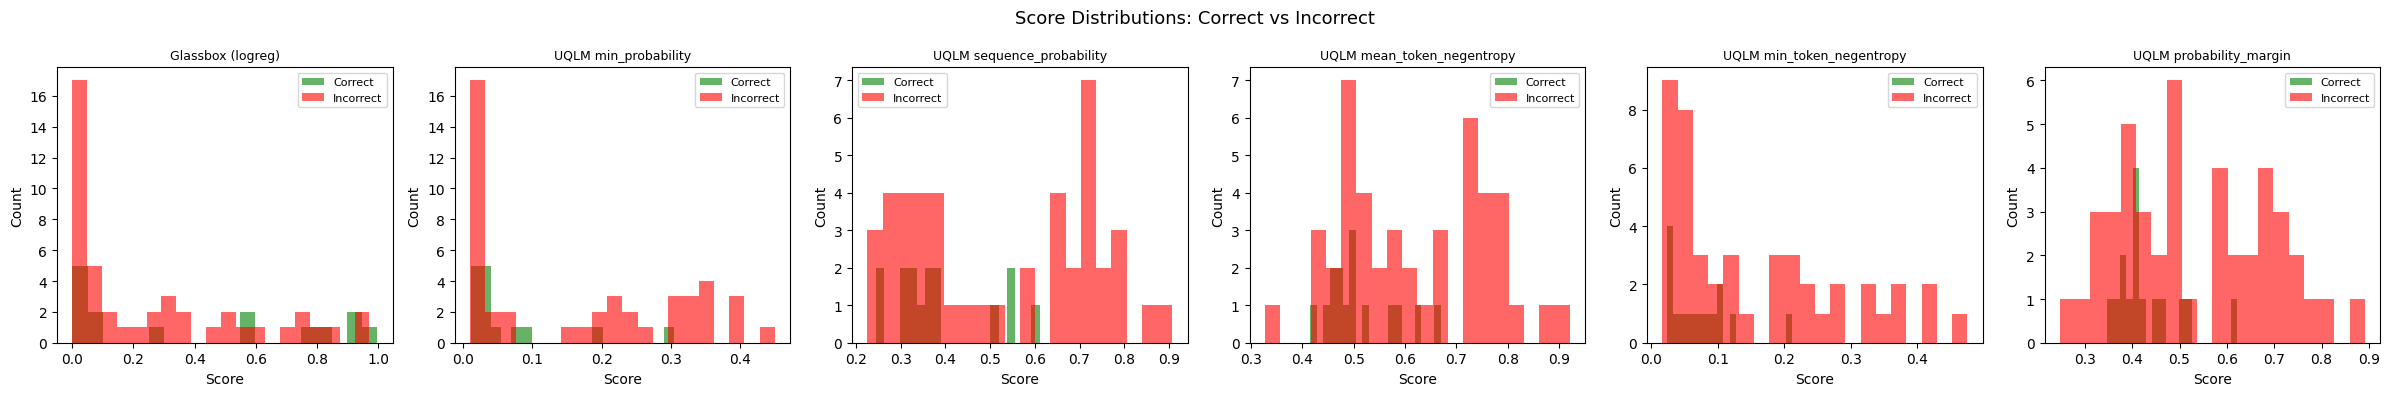

In [ ]:
if results is None:
    print("Skipping — only one class present.")
else:
    n_scorers = len(scorer_data)
    fig, axes = plt.subplots(1, n_scorers, figsize=(4 * n_scorers, 4))
    if n_scorers == 1:
        axes = [axes]
    correct_mask = y_test.astype(bool)

    for ax, (label, scores) in zip(axes, scorer_data):
        ax.hist(scores[correct_mask], bins=20, alpha=0.6, label="Correct", color="green")
        ax.hist(scores[~correct_mask], bins=20, alpha=0.6, label="Incorrect", color="red")
        ax.set_title(label, fontsize=9)
        ax.set_xlabel("Score")
        ax.set_ylabel("Count")
        ax.legend(fontsize=8)

    plt.suptitle("Score Distributions: Correct vs Incorrect", fontsize=13)
    plt.tight_layout()
    plt.show()

## 8. Feature Importance

Which Glassbox features (layers, feature types) contribute most to the classifier?

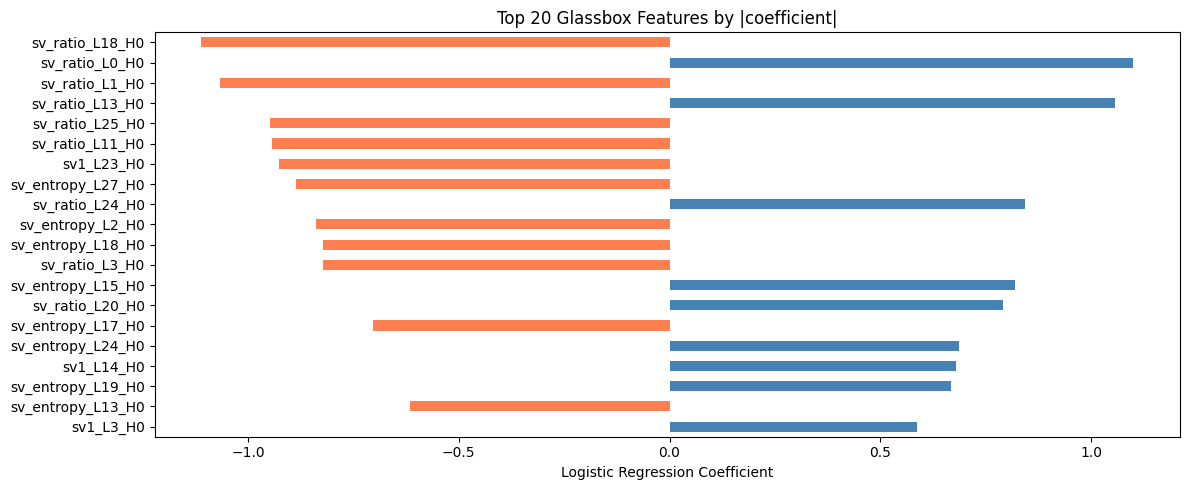

In [ ]:
if results is not None:
    coefs = pd.Series(clf.coef_[0], index=columns).sort_values(key=abs, ascending=False)

    fig, ax = plt.subplots(figsize=(12, 5))
    top_n = min(20, len(coefs))
    top = coefs.head(top_n)
    colors = ["steelblue" if v > 0 else "coral" for v in top.values]
    top.plot.barh(ax=ax, color=colors)
    ax.set_xlabel("Logistic Regression Coefficient")
    ax.set_title(f"Top {top_n} Glassbox Features by |coefficient|")
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()

## Summary

| Method | Signal source | Training needed | What it measures |
|---|---|---|---|
| UQLM min_probability | Token log-probs | No | Weakest-link token confidence |
| UQLM sequence_probability | Token log-probs | No | Average token confidence (LNTP) |
| UQLM mean_token_negentropy | Top-k log-probs | No | Mean per-token distributional sharpness |
| UQLM min_token_negentropy | Top-k log-probs | No | Worst-case token distributional sharpness |
| UQLM probability_margin | Top-k log-probs | No | Mean gap between top-1 and top-2 token probs |
| Glassbox (logreg) | Attention QK structure | Yes (logreg) | Spectral geometry of attention |

All methods require only a single generation pass. UQLM scores are
one-dimensional summaries of token probabilities. Glassbox provides a
high-dimensional view of attention structure across all layers.

**Next steps:**
- Add more Glassbox signals (routing, tracker, selfattn, laplacian)
- Add UQLM black-box scores (multi-generation consistency)
- Try larger models (Qwen2-7B-Instruct, Llama-3-8B-Instruct)
- Run on all 6 UQLM benchmark datasets
- Plot cost-accuracy Pareto frontier